Here, we filter the TF anndata object according to the extracted signaling network. We also embed the activity matrix in PCA/UMAP space.

In [1]:
import os
import ast
import json
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
# import umap

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp
from scLEMBAS import latent_separation as ls

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

# Embeddings

In [4]:
covariate_associations = ['drug']

In [5]:
pc_rank = tf_adata.uns['pca']['pca_rank']
pls_rank = tf_adata.uns['pls']['model_fit']['n_components']

In [11]:
drug = tf_adata.obs.drug.unique().tolist()[2]
ctrl_pert = 'DMSO_TF'
cell_line = tf_adata.obs.cell_line.unique().tolist()[2]

In [12]:
tf_adata_sub, r2_df = ls.pc_pipeline(
    adata = tf_adata,
    pert_ids = [drug, ctrl_pert],
    cat_ids = [cell_line], 
    n_components = pc_rank, # estimate out of 50
    pert_col = 'drug',
    cat_col = 'cell_line',
    get_hvgs = False, # tf activity doesn't use HVGs 
    run_umap = False,
    covariate_associations = ['drug'], 
    file_prefix = None,
    verbose = False,
    n_cores = n_cores,
    seed = 888,
    embkwrgs = {
        'cluster_data': False, 
        'scale': False,
        'pcakwrgs': {
            'use_highly_variable': False,
            'zero_center': False
        }    
    }
)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


drug


100%|██████████████████████████████████████████| 15/15 [00:00<00:00, 830.81it/s]


drug


100%|███████████████████████████████████████████| 15/15 [00:03<00:00,  4.74it/s]


The two PC components that best univariately separate by drug are components 11 and 13 explaining 1.54% and 1.47% of variance, respectively


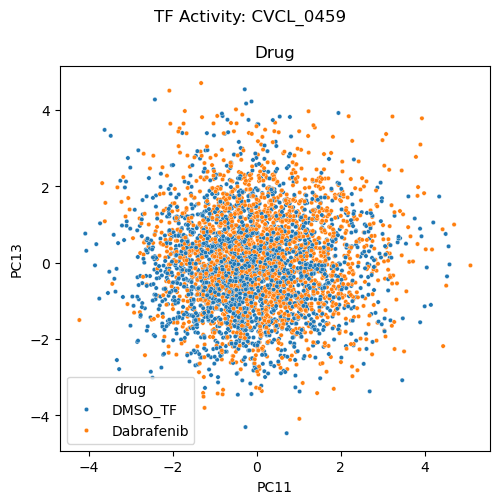

In [13]:
top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
ls.visualize_latent_space(
    adata = tf_adata_sub, 
    latent_label = 'pca', 
    covariates = ['drug'],
    panel_titles = ['Drug'],
    components = top_components_drug,
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity: ' + cell_line, 
    legend = True, 
    seed = 888, 
    file_name = None
)

In [16]:
tf_adata_sub, r2_df = ls.pls_da_pipeline(
    adata = tf_adata, 
    pert_ids = [drug, ctrl_pert],
    cat_ids = cell_line,
    n_components = pls_rank, 
    pert_col = 'drug', 
    cat_col = 'cell_line', 
    separate_by = 'perturbation', 
    control_confounders = [], 
    covariate_associations = covariate_associations,
    scale = False, # TF activity already Z-scored
    run_umap = True, 
    file_prefix = None, 
    verbose = True,
    seed = seed, 
    n_cores = n_cores
)


Fit PLS Model
Calculate covariate - PLS associations
drug


100%|██████████████████████████████████████████| 12/12 [00:00<00:00, 667.55it/s]


drug


100%|███████████████████████████████████████████| 12/12 [00:02<00:00,  4.76it/s]
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Get UMAP


The two PLS components that best univariately separate by drug are components 1 and 2 explaining 34.24% and 7.62% of variance, respectively


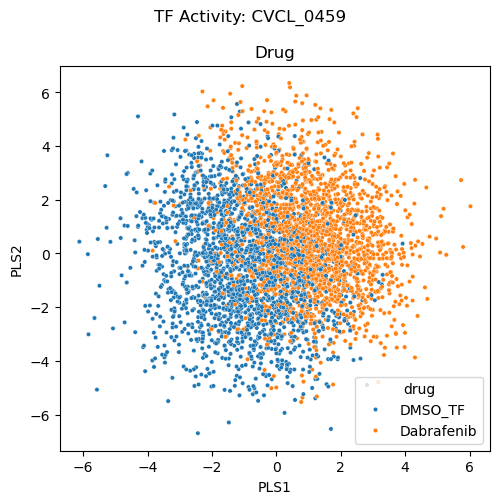

In [17]:
top_components_drug = ls.get_top_components(r2_df, top_components_cov = 'drug')
ls.visualize_latent_space(
    adata = tf_adata_sub, 
    latent_label = 'pls', 
    covariates = ['drug'],
    panel_titles = ['Drug'],
    components = top_components_drug,
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity: ' + cell_line, 
    legend = True, 
    seed = 888, 
    file_name = None
)

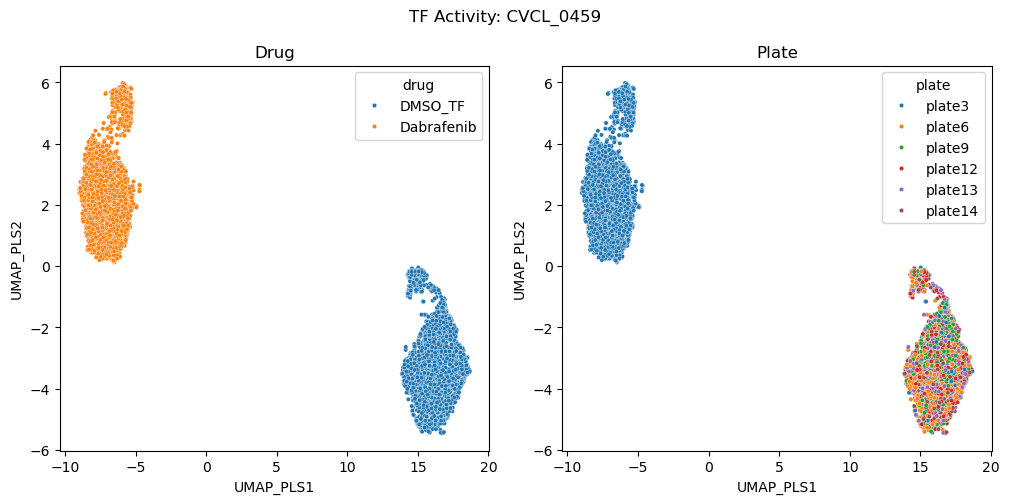

In [20]:
ls.visualize_latent_space(
    adata = tf_adata_sub, 
    latent_label = 'umap_pls', 
    covariates = ['drug', 'plate'],
    panel_titles = ['Drug', 'Plate'],
    components = top_components_drug,
    n_frac = 1, 
    frac_col = None, 
    fig_title = 'TF Activity: ' + cell_line, 
    legend = True, 
    seed = 888, 
    file_name = None
)